# SPI-TAP non-interactive run
Set parameters, run until source shortlist, then continue.

## Selections and directory build

In [ ]:
import os
import spitap.spi_obs as st

# directory with all analysis results

obsdir = "obs"

RUN = {
    "src_dir": "test",
    "full_name": "Crab", "ra": None, "dec": None, #83.6331, 22.0145,
    # "full_name": "none", "ra": 83.6331, "dec": 22.0145,
    "date_start": "2005-01-01",
    "date_end": "2005-06-01",
    "off_angle": 10.0, # angle from main source to pointing centers
    "evt_type": "SE",
    "binning_type": "log",
    "emin": 20.0,
    "emax": 400.0,
    "nbins": 20,
    "e_channels_bounds": None,
    "e_channels_scales": None,
    "overwrite_date_dir": False,
    "skip_spiselectscw_par": True,
    "zenith_angle": 10.0, # angle from pointing centers to sources 
}

In [ ]:
# initial_dir = os.getcwd()
initial_dir = "/home/tbouchet/spi-tap" # REPLACE WITH LOCATION OF NOTEBOOK
initial_env = os.environ.copy()

obs = st.ObsSPI(
    main_dir=obsdir,
    initial_dir=initial_dir,
    initial_env=initial_env,
    testrun=False,
)
nearby_df = obs.run_analysis_noninteractive(**RUN, src_sel=None)
nearby_df

## Run analysis

In [ ]:
# choose source selection manually here (0 to select all)
src_sel = 0
# src_sel = [0, 1, 3]

In [ ]:
main_src_var = {
    "main_src_var_unit": "d",
    "main_src_var_n": "3",
    "main_src_var_type": "i"
    }

spimodfit_par = {
    # variability of all other sources
    "src_var_n": "2",
    "src_var_unit": "d",
    "src_var_type": "i",
    # variability of background
    "bkg_var_n": "1",
    "bkg_var_unit": "p",
    "bkg_var_type": "i",
    "spimodfit_clobber": True
}

obs.select_brightest(src_sel)
# this method can be repeated with different variabilities for specific sources by changing src_name
obs.select_src_var(**main_src_var, src_name= None)

# change variability of all remaining sources
obs.make_spimodfit_par(**spimodfit_par)
obs.analyze_spimodfit(verbose=True)
obs.generate_response(clobber='y')
os.chdir('..') # back to energy dir

In [ ]:
print(obs)

## Reset analysis

In [ ]:
os.environ.clear()
os.environ.update(initial_env)
os.chdir(initial_dir)
print("Environment and directory restored.")

# Check residuals and light-curves

In [78]:
import spitap.analyze_res as res

Building result data frames...


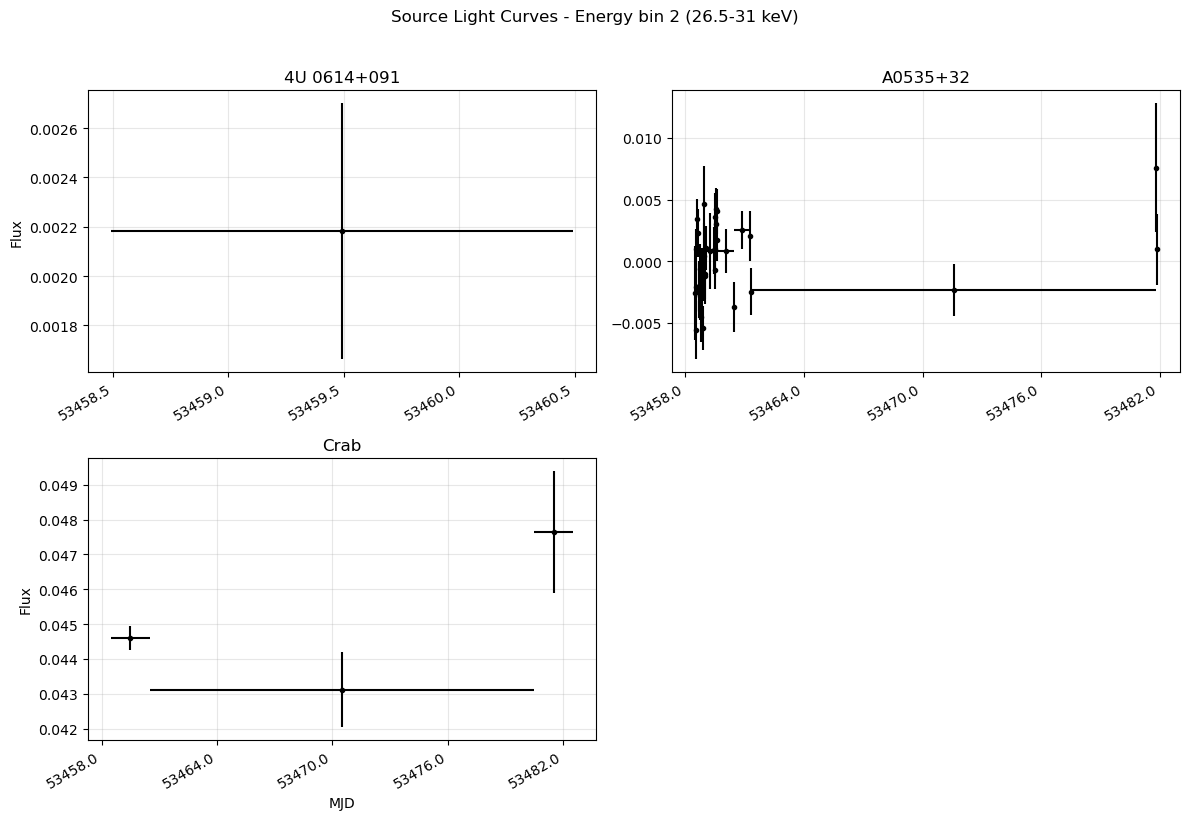

In [ ]:
spec_path = obs.spec_path
# spec_path = "/home/tbouchet/SPI_SOURCES/obs/test/2005-01-01_2005-06-01_10deg/20_400_20log_SE/fit_2di_1pi"
spi_result = res.SPIResult(spec_path)
axes=spi_result.plot_source_lightcurves(energy_bin=2, ncols=2, date_type='MJD', figsize_per_panel=(6,4))

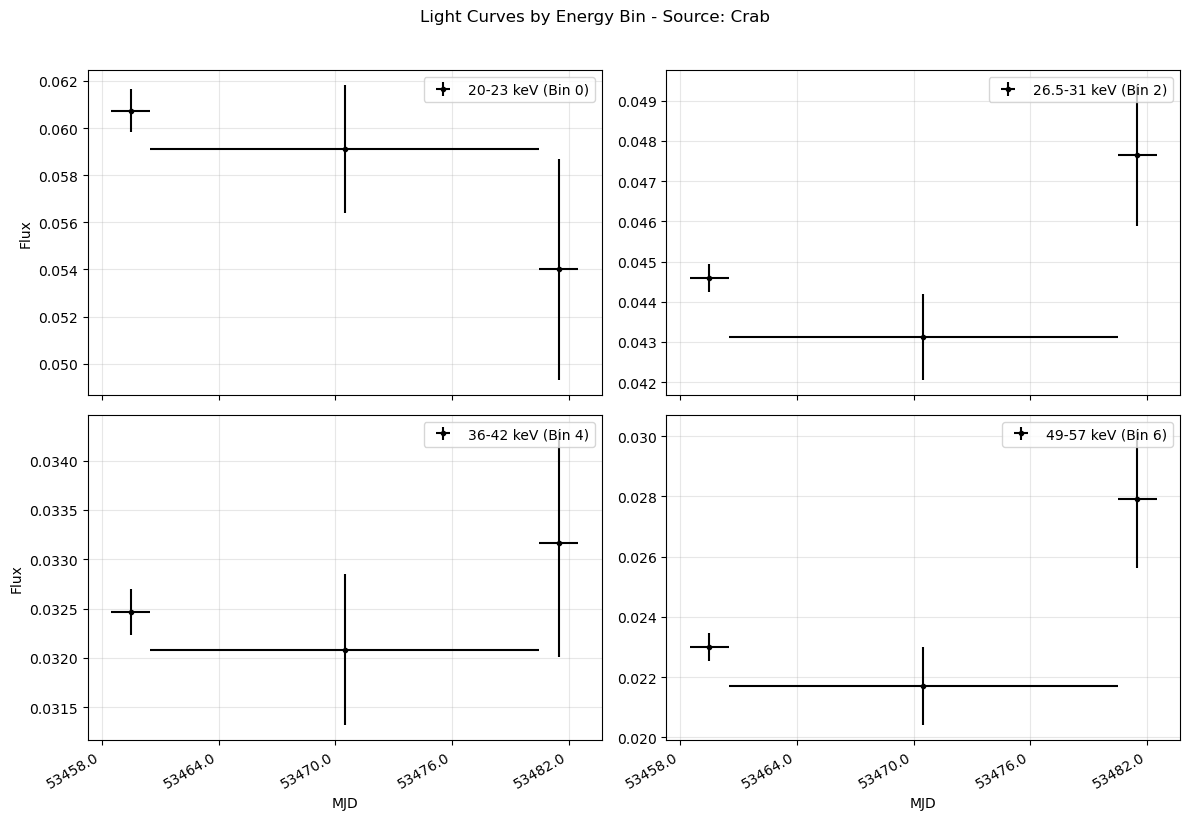

In [81]:
axes=spi_result.plot_energybin_lightcurves_for_source(
"Crab",
ncols=2,
date_type="MJD",
figsize_per_panel=(6, 4),
energy_bins=[0,2,4,6]
)